zmienna docelowa: kolumna Class

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import os
import numpy as np

In [2]:
data = pd.read_excel("Pistachio_28_Features_Dataset/Pistachio_28_Features_Dataset.xlsx", sheet_name=0, engine='openpyxl')
df = data.copy()

Cel biznesowy: Na podstawie zdjęć wyznaczyć rodzaj pistacji: Siirt vs Kirmizi

![siirt](siirt.png)
![kirmizi](kirmizi.png)

In [5]:
print(df.head())

    Area  Perimeter  Major_Axis  Minor_Axis  Eccentricity   Eqdiasq  Solidity  \
0  63391   1568.405    390.3396    236.7461        0.7951  284.0984    0.8665   
1  68358   1942.187    410.8594    234.7525        0.8207  295.0188    0.8765   
2  73589   1246.538    452.3630    220.5547        0.8731  306.0987    0.9172   
3  71106   1445.261    429.5291    216.0765        0.8643  300.8903    0.9589   
4  80087   1251.524    469.3783    220.9344        0.8823  319.3273    0.9657   

   Convex_Area  Extent  Aspect_Ratio  ...  StdDev_RR  StdDev_RG  StdDev_RB  \
0        73160  0.6394        1.6488  ...    17.7206    19.6024    21.1342   
1        77991  0.6772        1.7502  ...    26.7061    27.2112    25.1035   
2        80234  0.7127        2.0510  ...    19.0129    20.0703    20.7006   
3        74153  0.7028        1.9879  ...    18.1773    18.7152    29.7883   
4        82929  0.7459        2.1245  ...    23.4298    24.0878    23.1157   

   Skew_RR  Skew_RG  Skew_RB  Kurtosis_RR  K

![p](pistacja.png)

In [9]:
print( df['Class'].value_counts())

Class
Kirmizi_Pistachio    1232
Siirt_Pistachio       916
Name: count, dtype: int64


In [10]:
print(df.isnull().sum())
print(df.describe())

Area             0
Perimeter        0
Major_Axis       0
Minor_Axis       0
Eccentricity     0
Eqdiasq          0
Solidity         0
Convex_Area      0
Extent           0
Aspect_Ratio     0
Roundness        0
Compactness      0
Shapefactor_1    0
Shapefactor_2    0
Shapefactor_3    0
Shapefactor_4    0
Mean_RR          0
Mean_RG          0
Mean_RB          0
StdDev_RR        0
StdDev_RG        0
StdDev_RB        0
Skew_RR          0
Skew_RG          0
Skew_RB          0
Kurtosis_RR      0
Kurtosis_RG      0
Kurtosis_RB      0
Class            0
dtype: int64
                Area    Perimeter   Major_Axis   Minor_Axis  Eccentricity  \
count    2148.000000  2148.000000  2148.000000  2148.000000   2148.000000   
mean    79950.655493  1425.971751   446.248968   238.311842      0.840219   
std     13121.737799   375.565503    32.445304    30.310695      0.048759   
min     29808.000000   858.363000   320.344500   133.509600      0.504900   
25%     71936.750000  1170.996250   426.508750   21

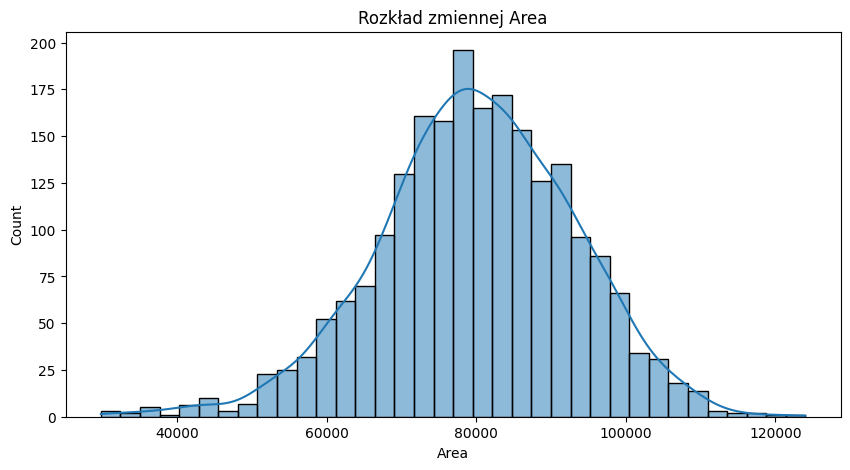

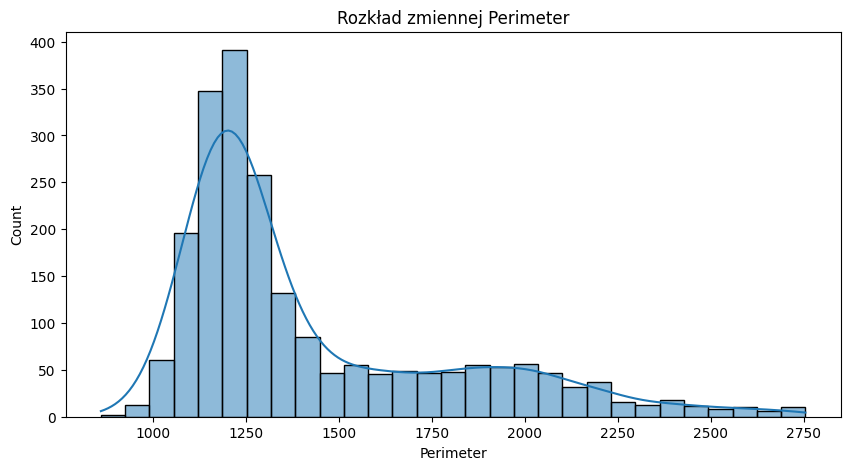

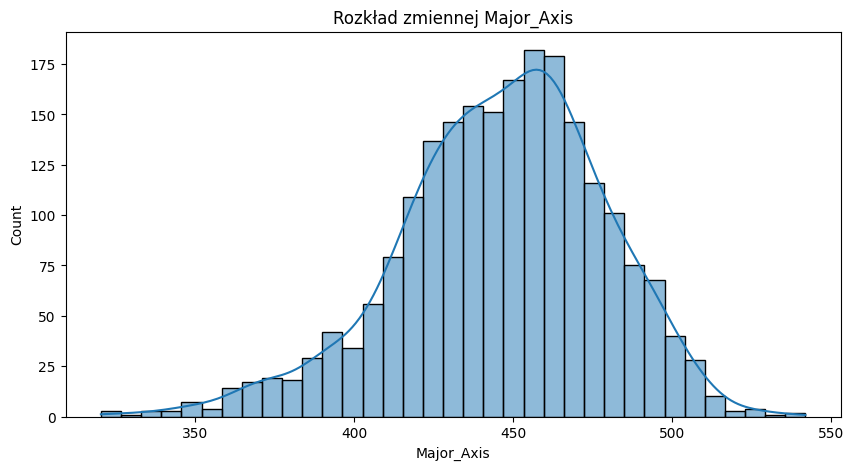

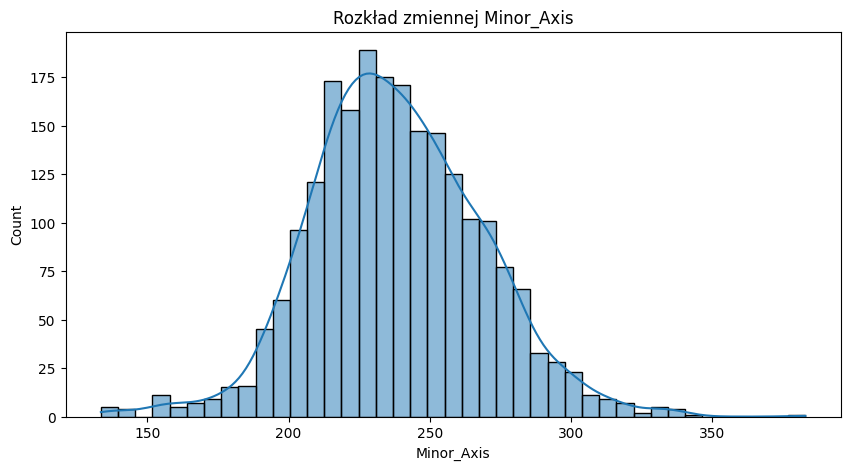

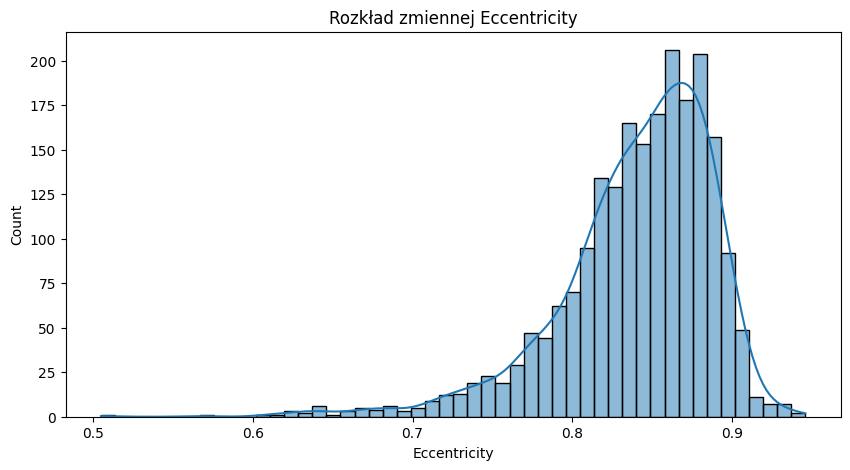

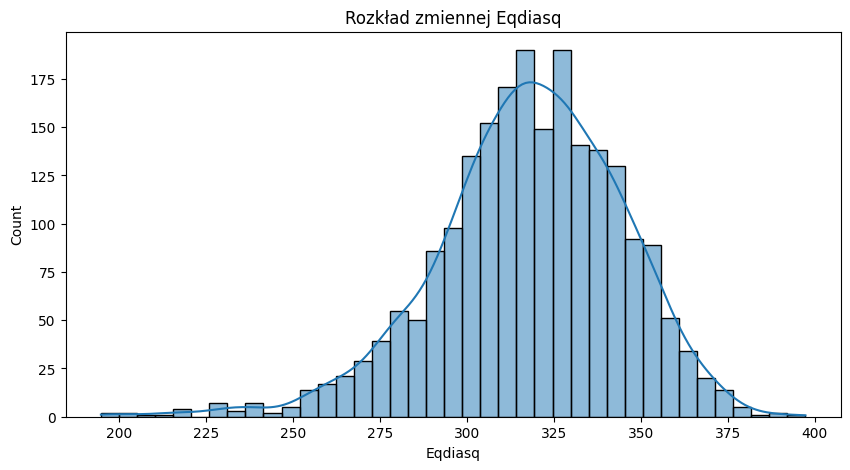

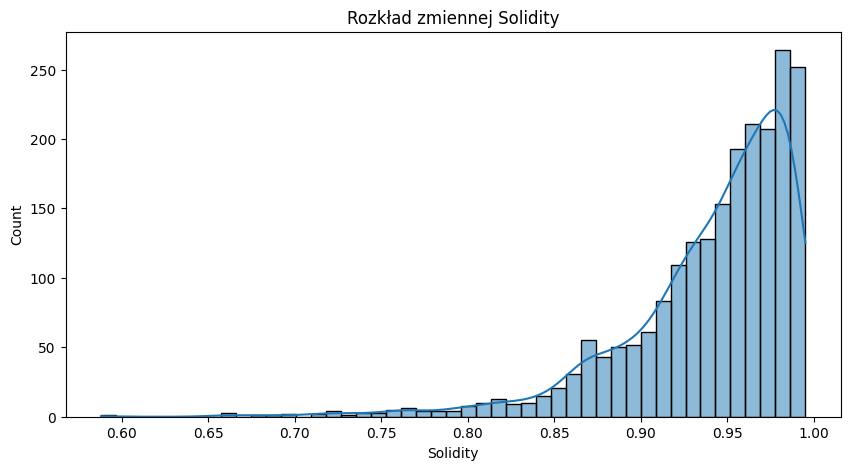

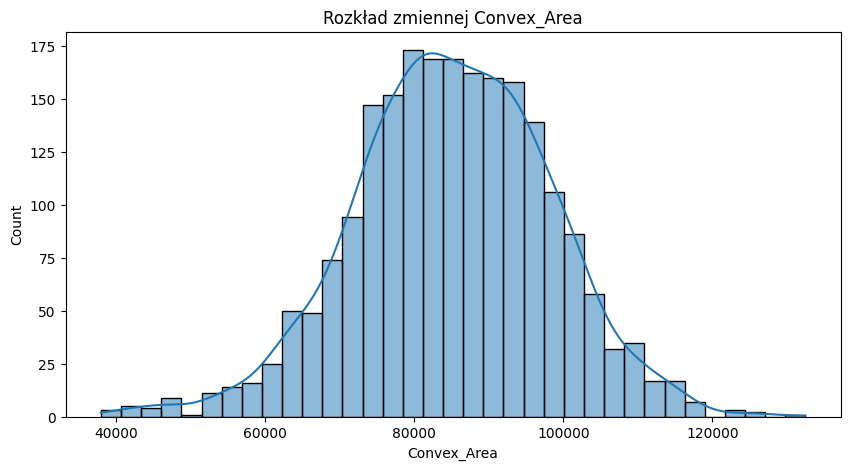

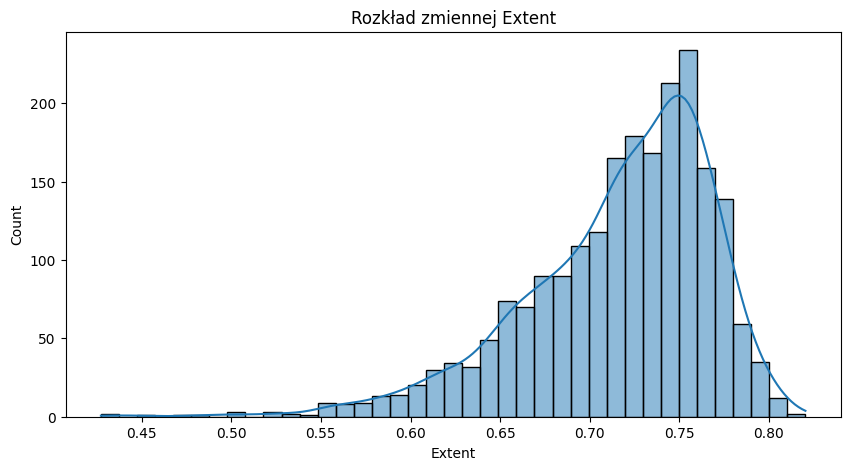

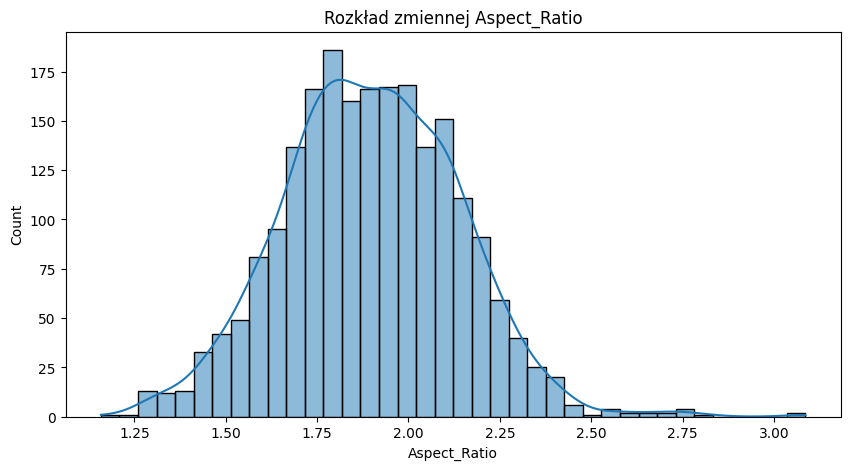

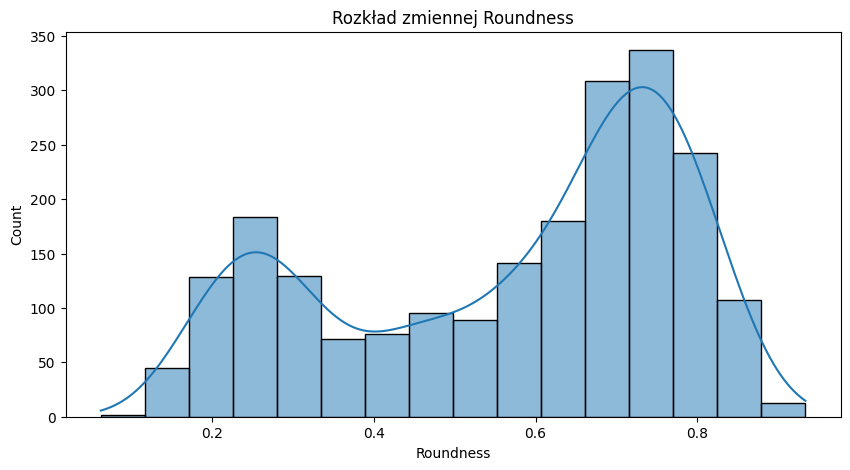

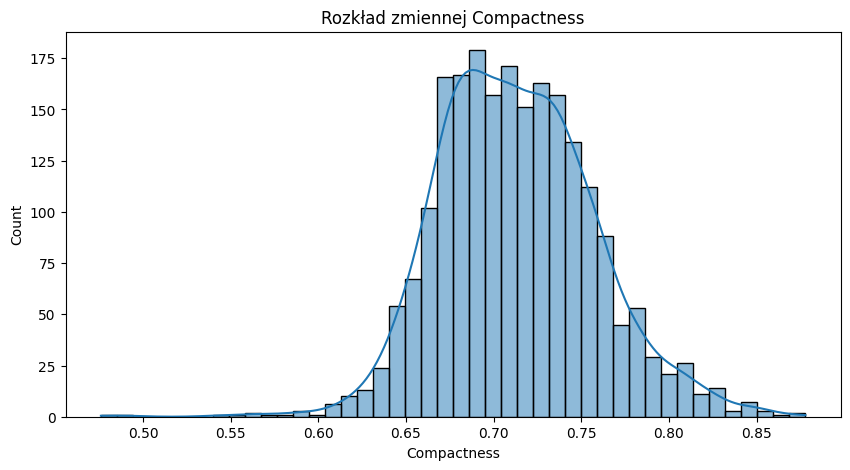

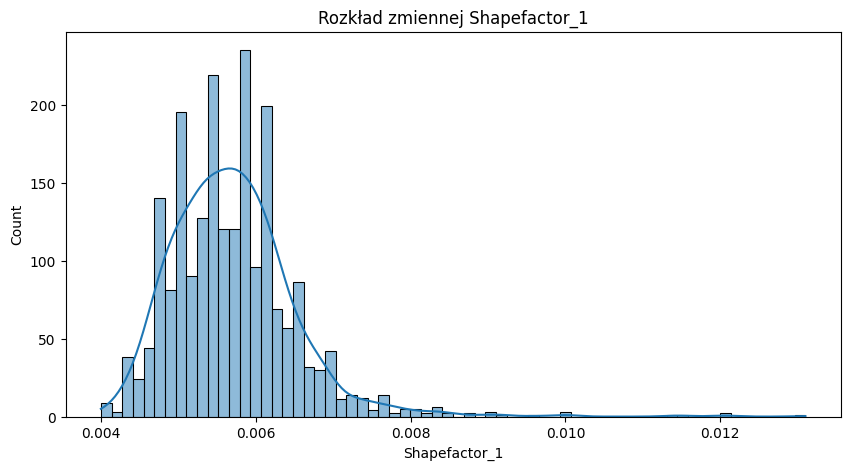

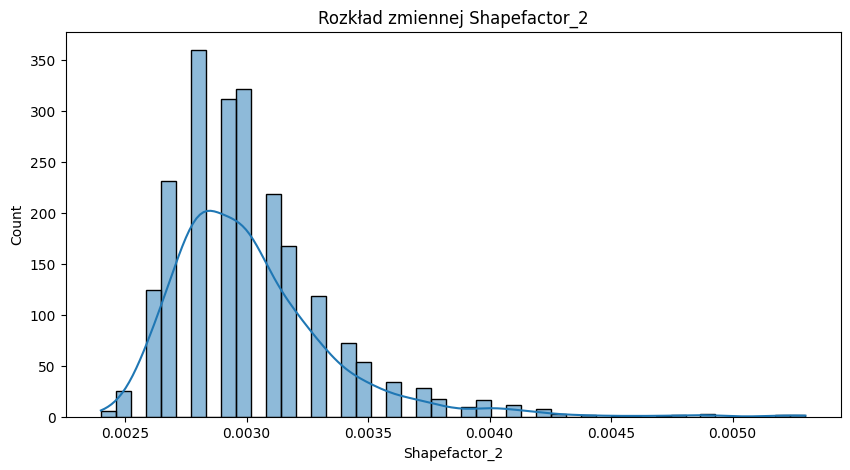

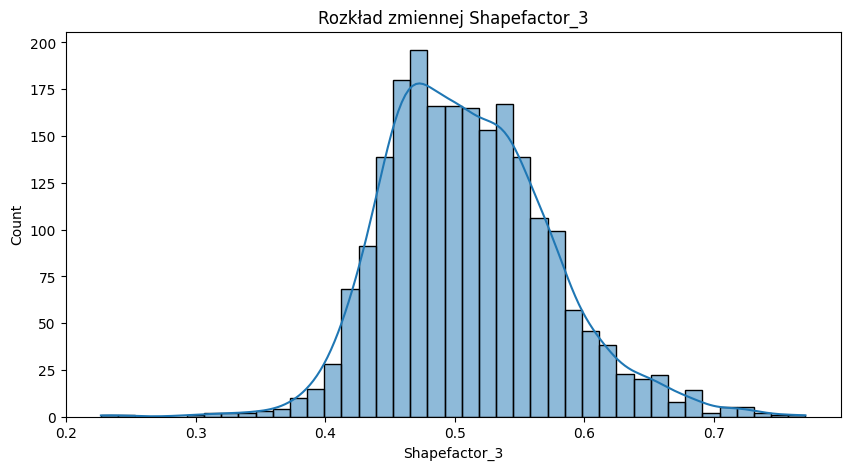

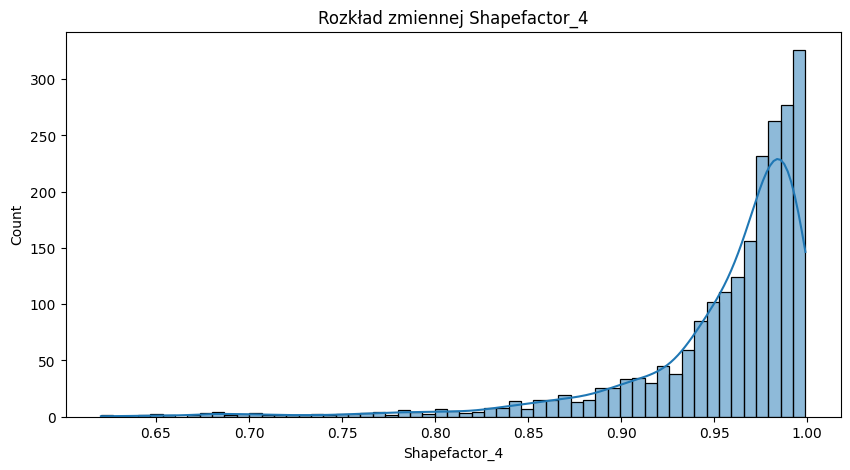

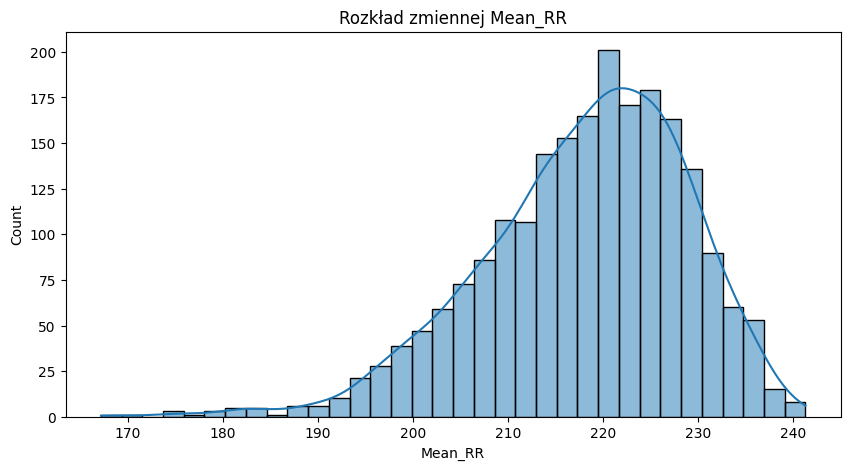

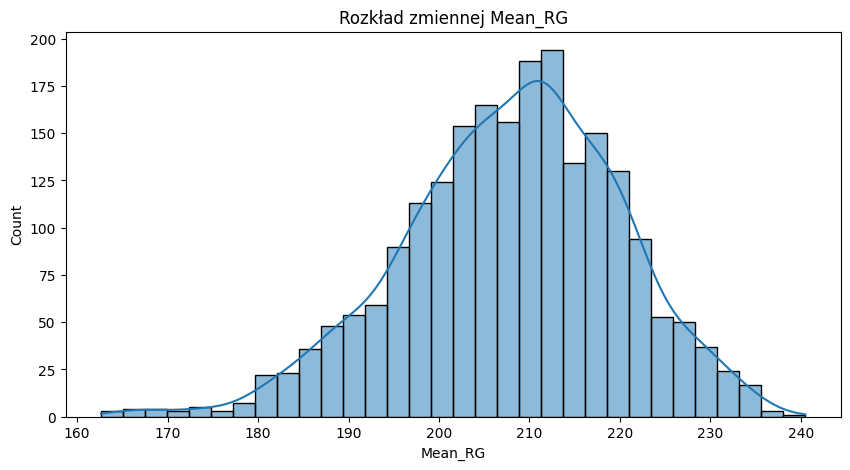

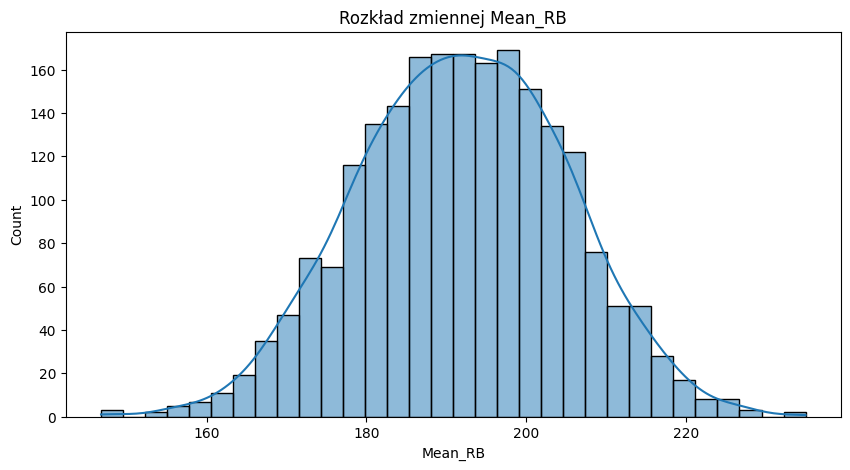

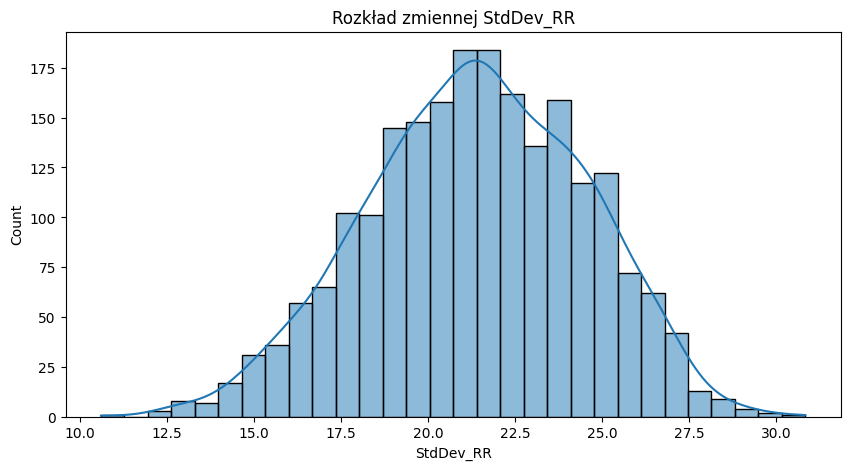

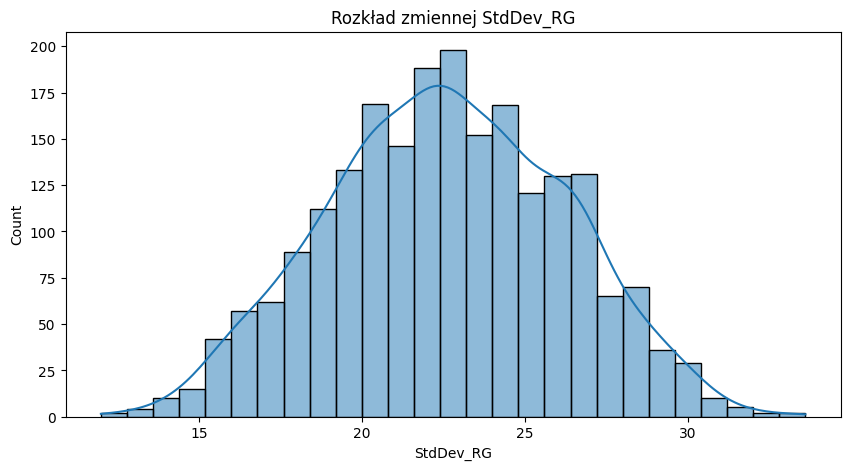

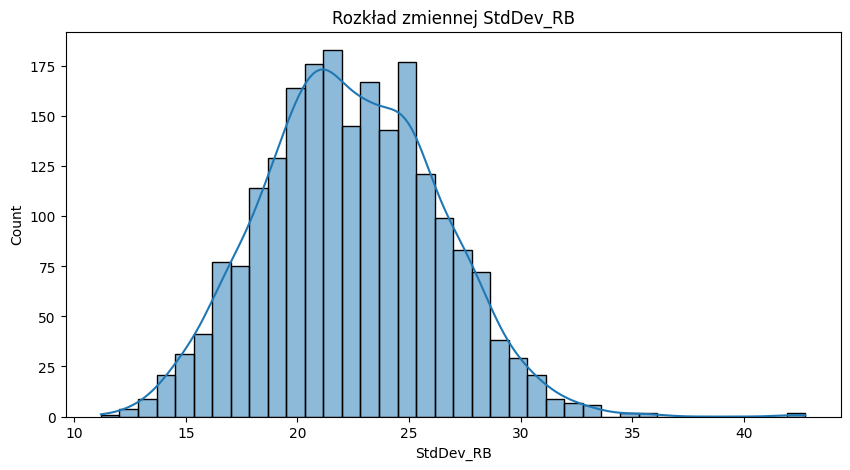

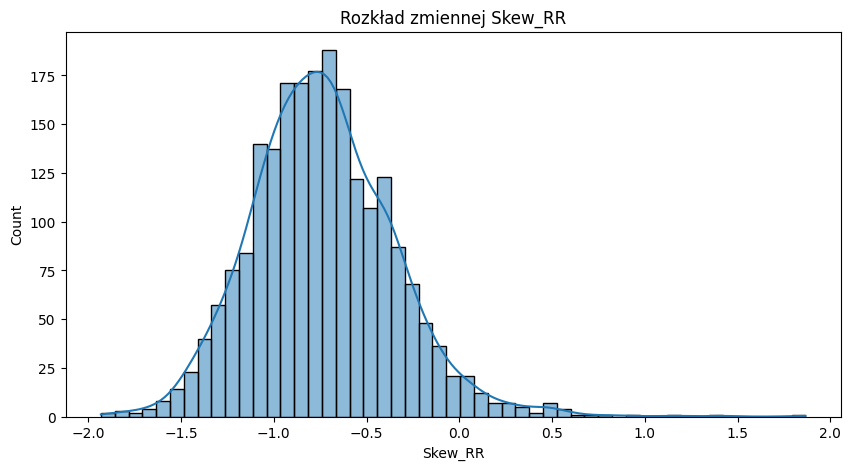

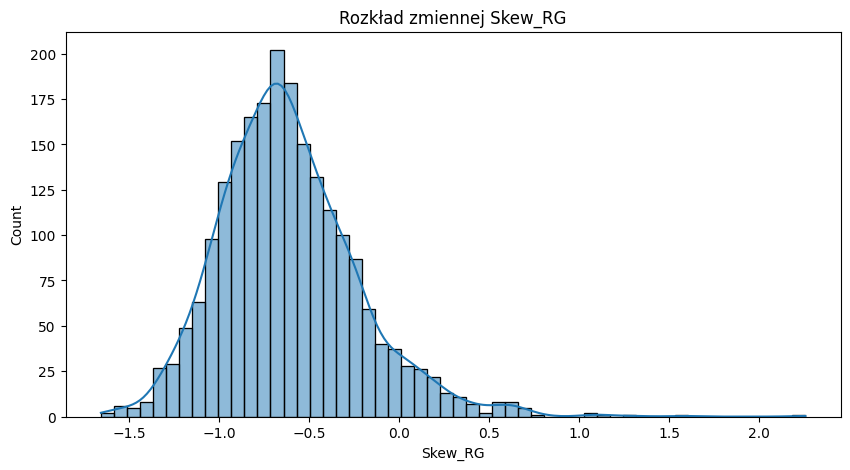

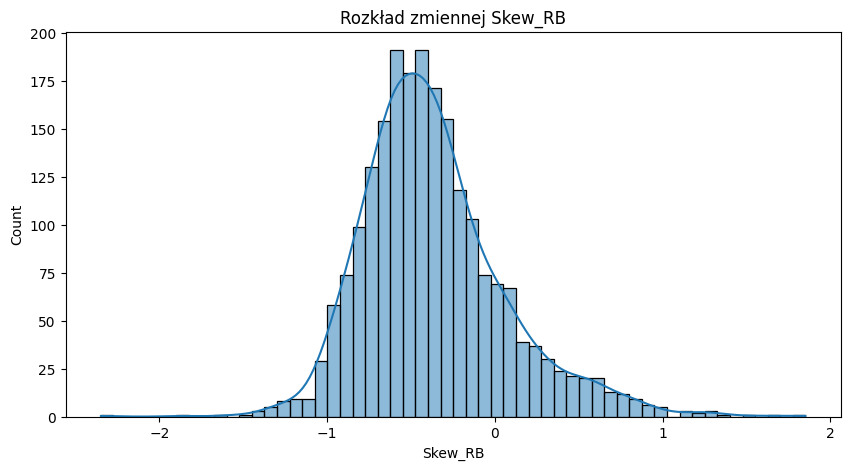

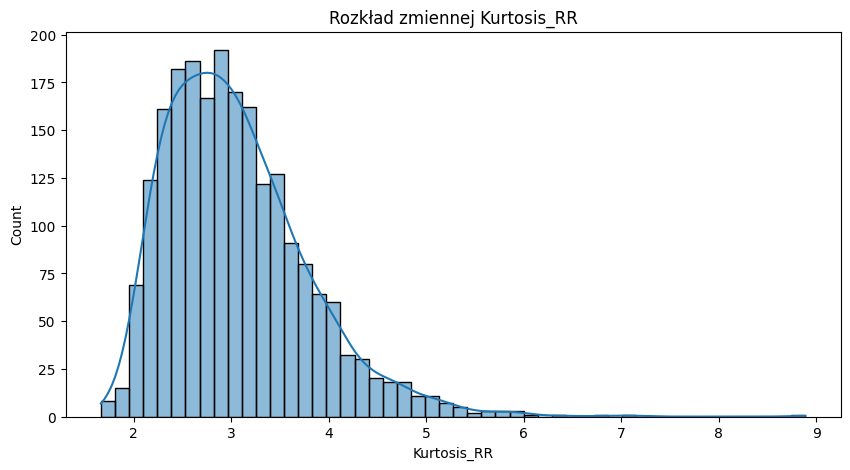

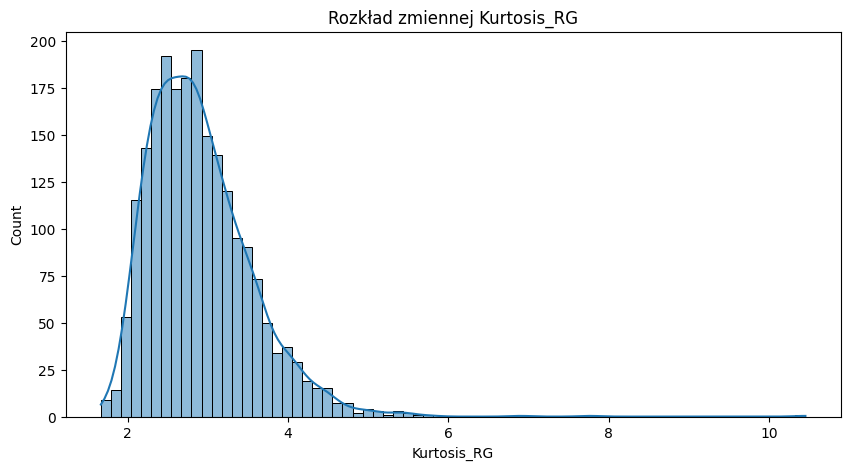

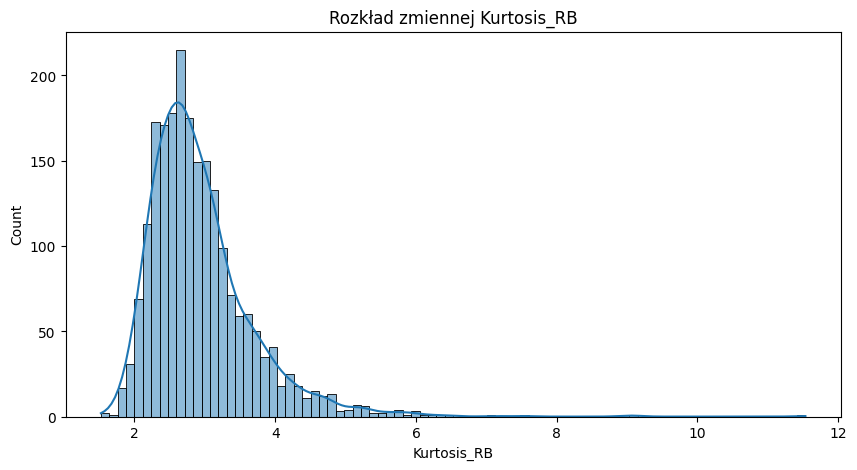

In [10]:
num_cols = df.select_dtypes(include=['int64','float64']).columns
for col in num_cols:
    plt.figure(figsize=(10,5))
    sns.histplot(df[col], kde = True)
    plt.title(f"Rozkład zmiennej {col}")
    plt.show()
    print("\n")

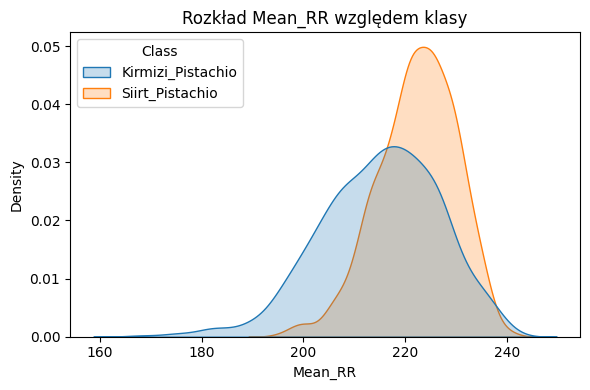

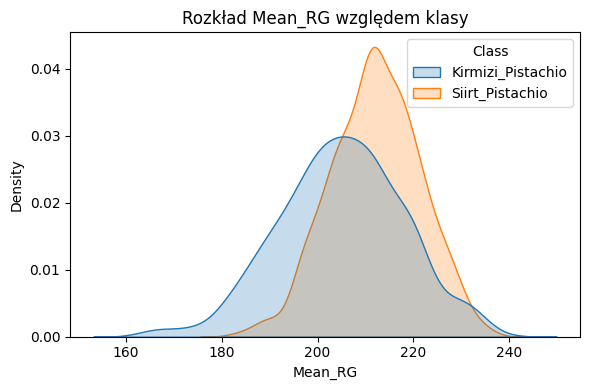

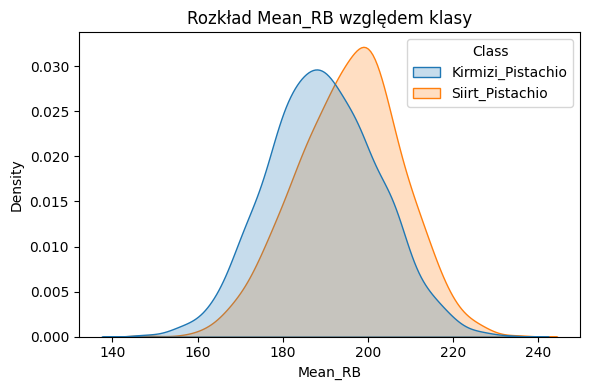

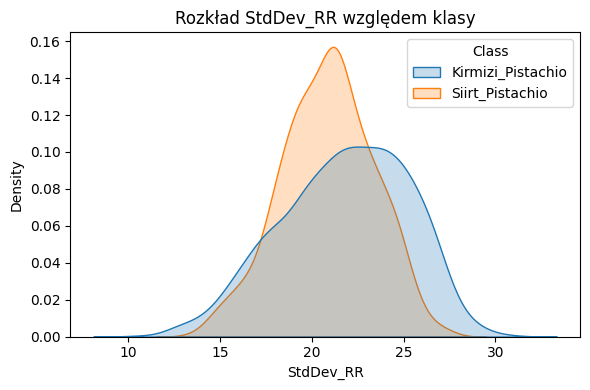

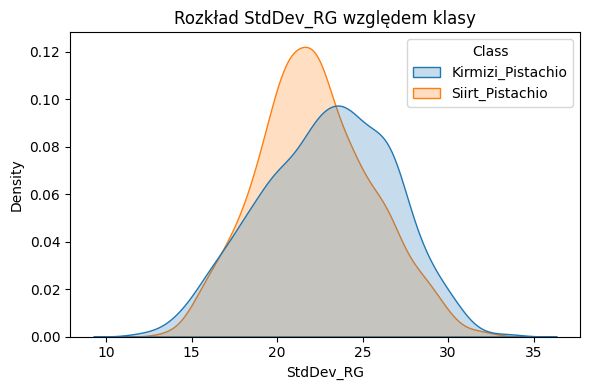

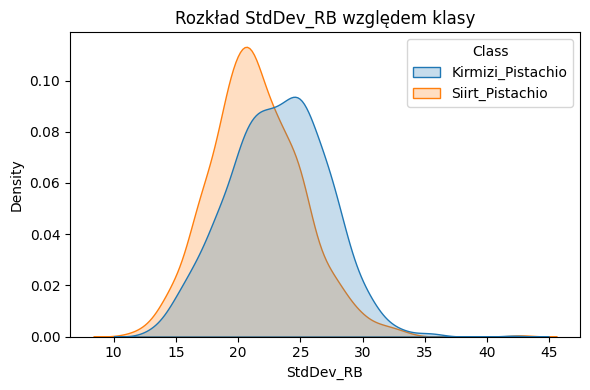

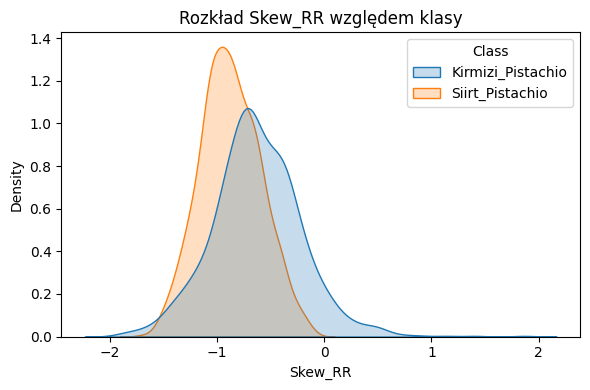

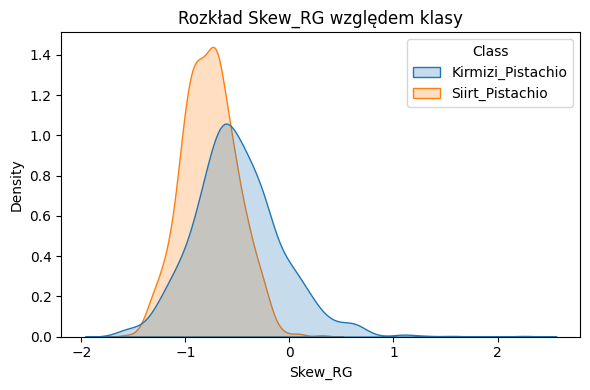

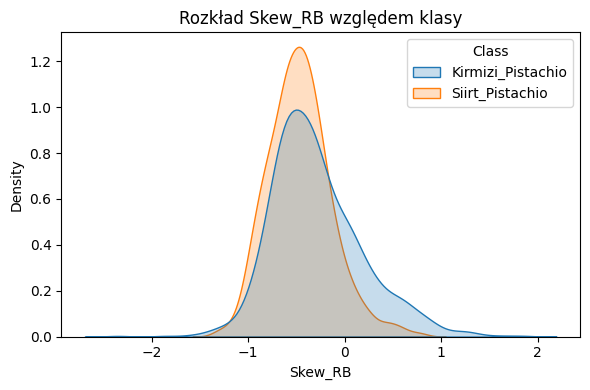

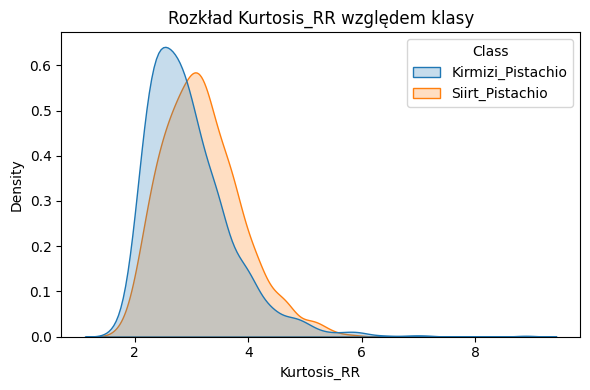

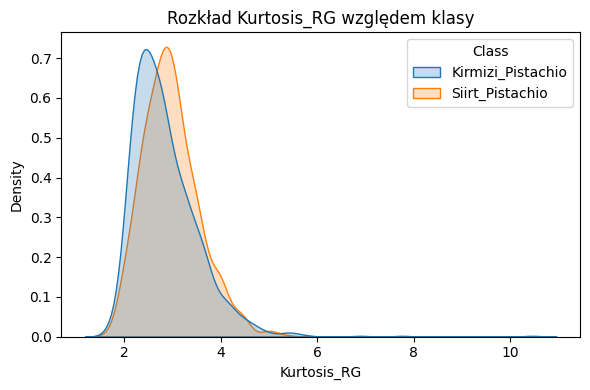

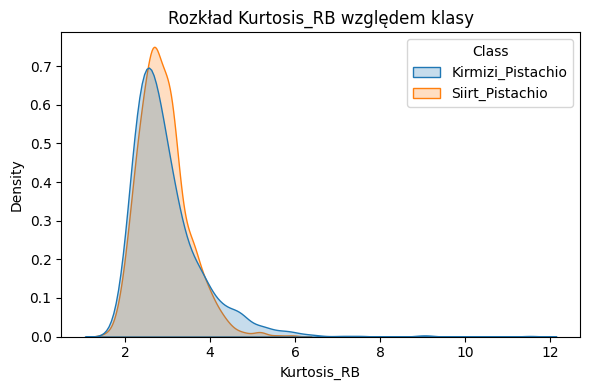

In [53]:
#analiza kanałów RGB
rgb_cols = [
    'Mean_RR', 'Mean_RG', 'Mean_RB',
    'StdDev_RR', 'StdDev_RG', 'StdDev_RB',
    'Skew_RR', 'Skew_RG', 'Skew_RB',
    'Kurtosis_RR', 'Kurtosis_RG', 'Kurtosis_RB'
]

rgb_df = df[rgb_cols + ['Class']]

for col in rgb_cols:
    plt.figure(figsize=(6, 4))
    sns.kdeplot(data=rgb_df, x=col, hue='Class', fill=True, common_norm=False)
    plt.title(f'Rozkład {col} względem klasy')
    plt.tight_layout()
    plt.show()

In [60]:
group1 = df[df['Class'] == 'Kirmizi_Pistachio']
group2 = df[df['Class'] == 'Siirt_Pistachio']

from scipy.stats import ttest_ind
for col in rgb_cols:
    stat, p = ttest_ind(group1[col], group2[col], equal_var=False)
    print(f"{col:<20}: p-value = {p:.5f}")


Mean_RR             : p-value = 0.00000
Mean_RG             : p-value = 0.00000
Mean_RB             : p-value = 0.00000
StdDev_RR           : p-value = 0.00000
StdDev_RG           : p-value = 0.00000
StdDev_RB           : p-value = 0.00000
Skew_RR             : p-value = 0.00000
Skew_RG             : p-value = 0.00000
Skew_RB             : p-value = 0.00000
Kurtosis_RR         : p-value = 0.00000
Kurtosis_RG         : p-value = 0.00006
Kurtosis_RB         : p-value = 0.01214


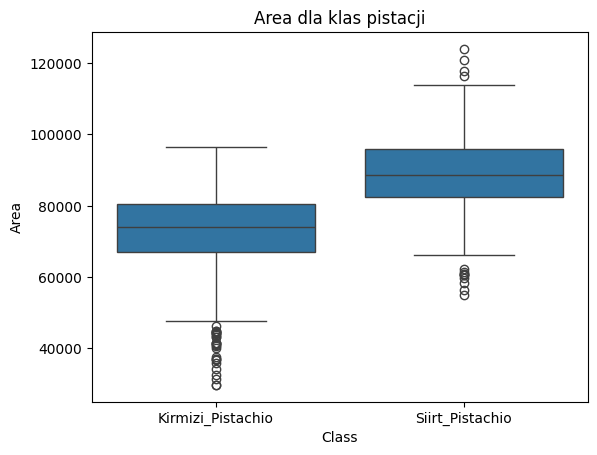

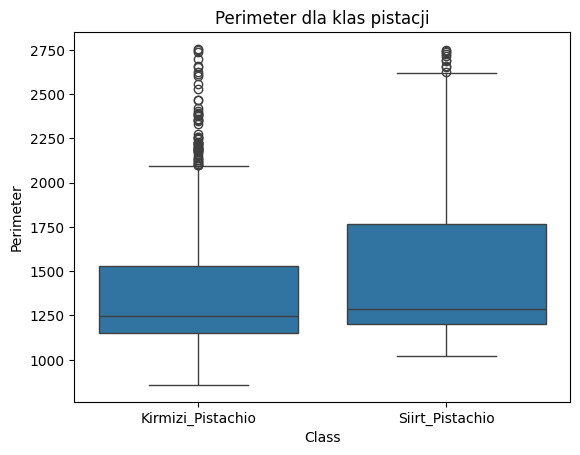

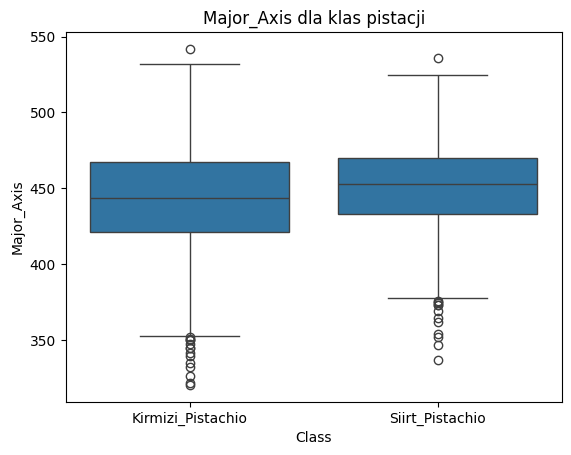

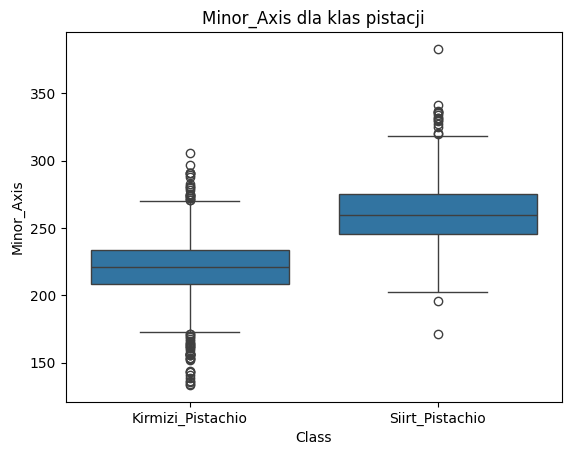

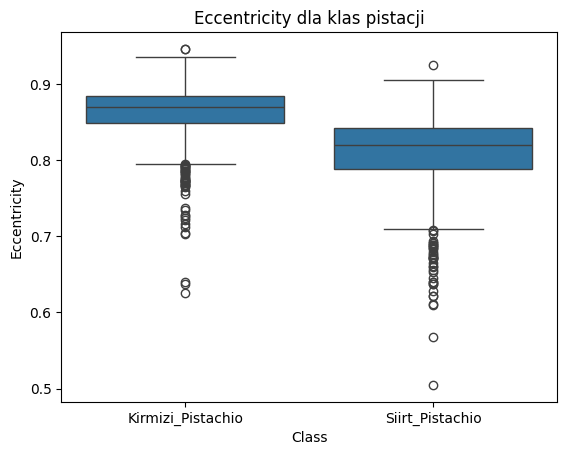

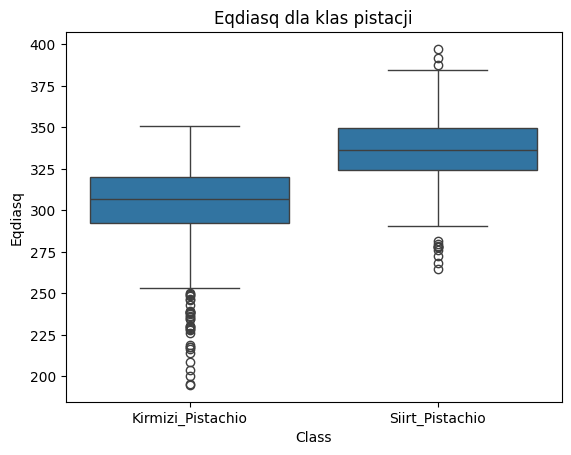

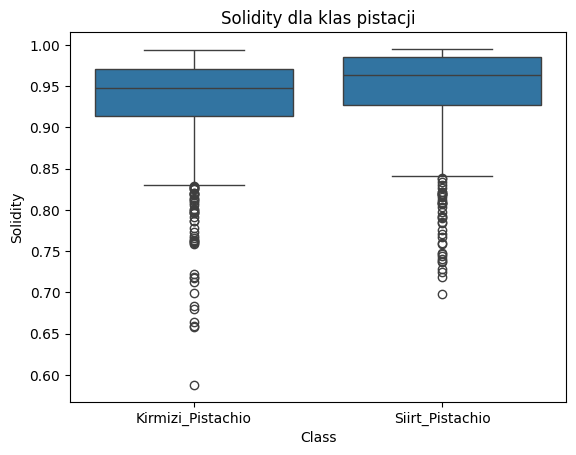

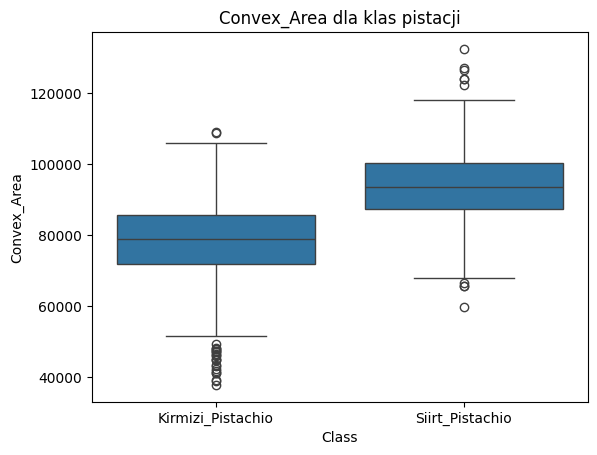

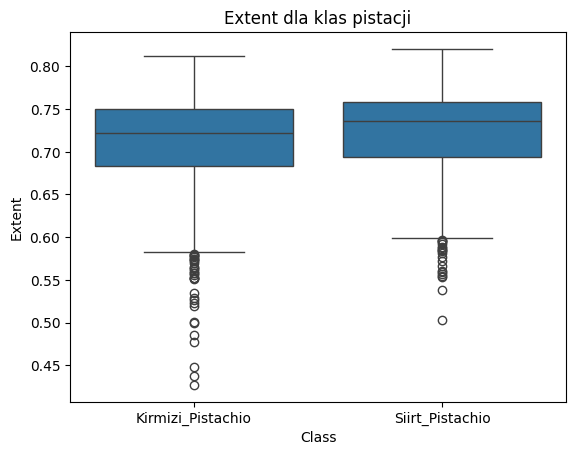

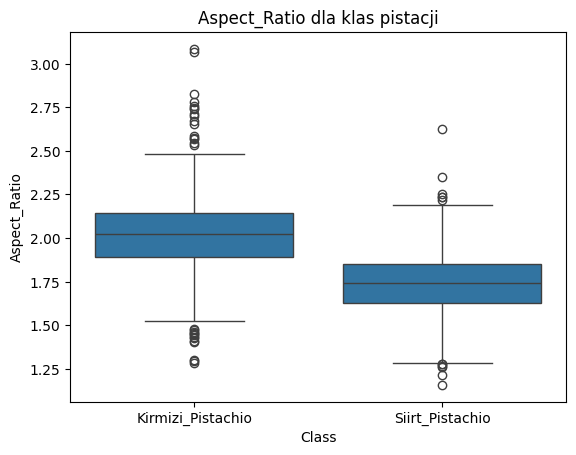

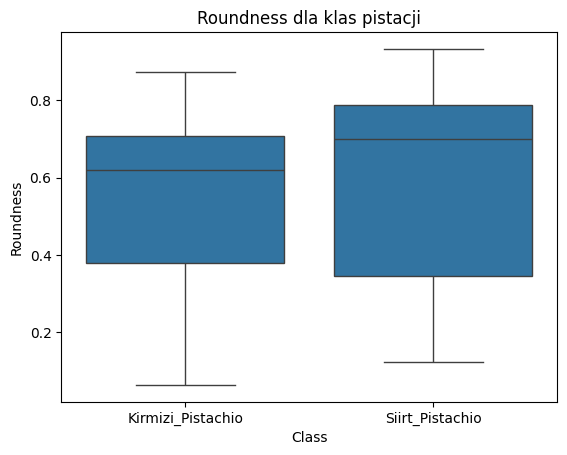

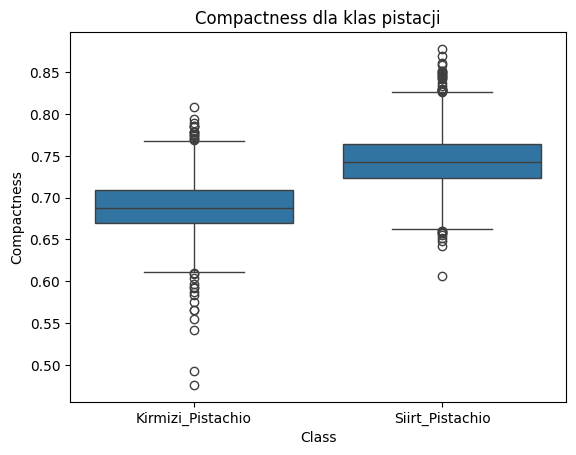

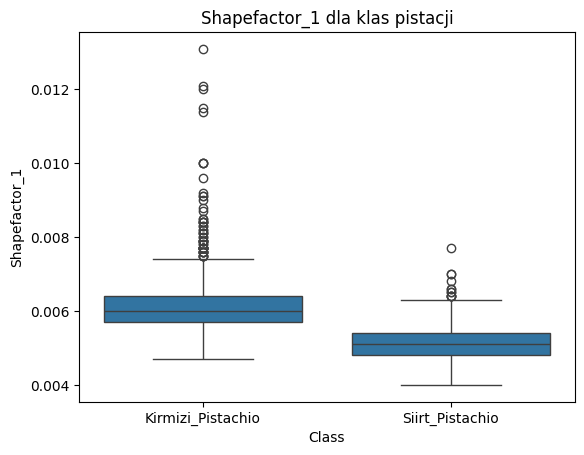

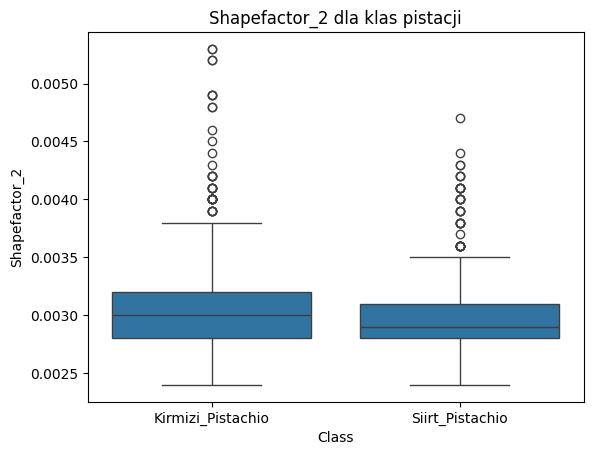

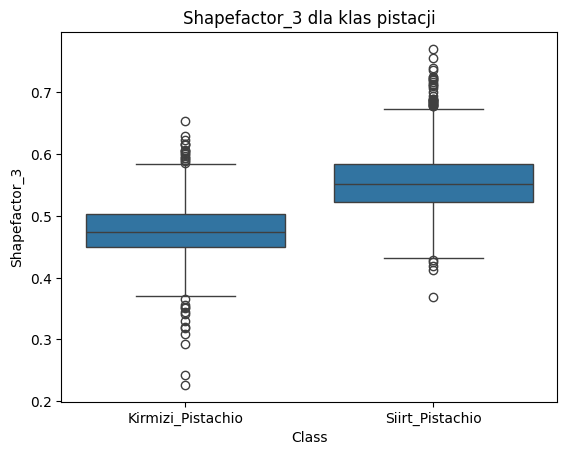

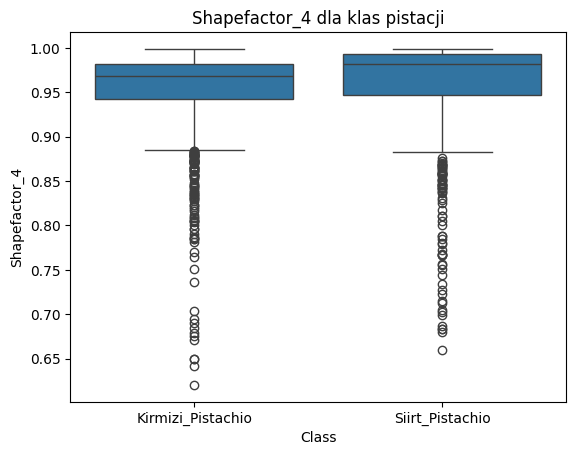

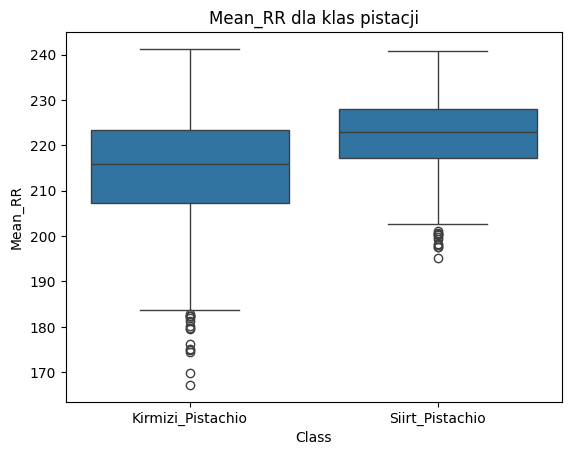

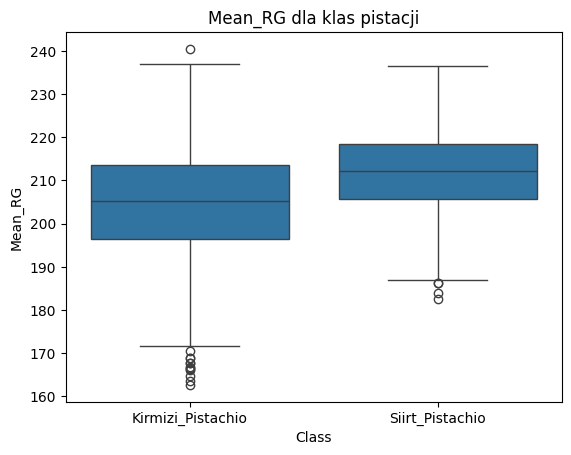

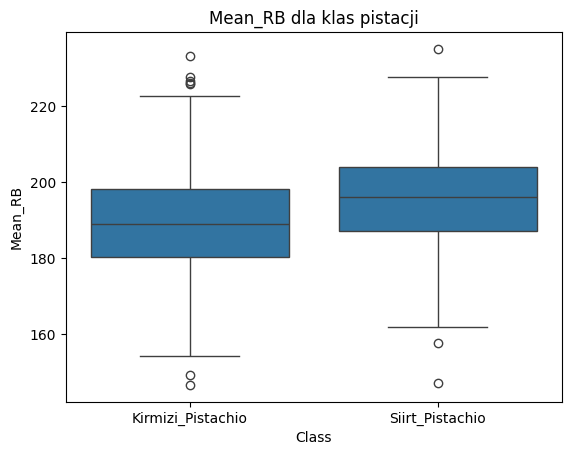

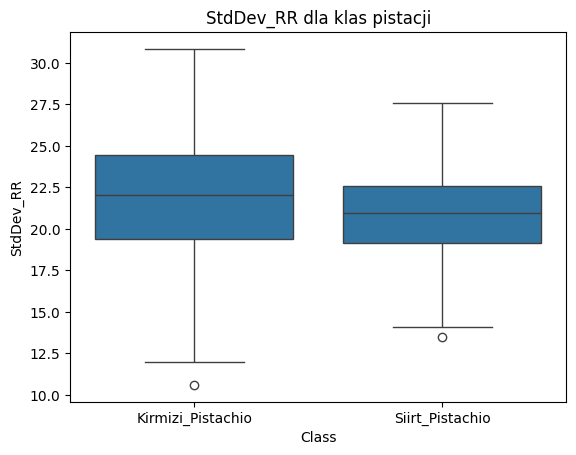

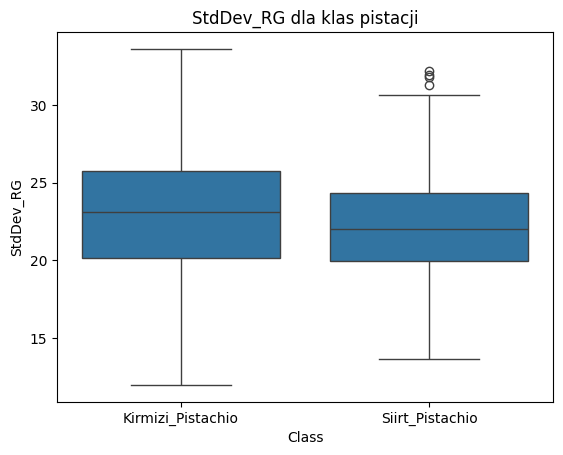

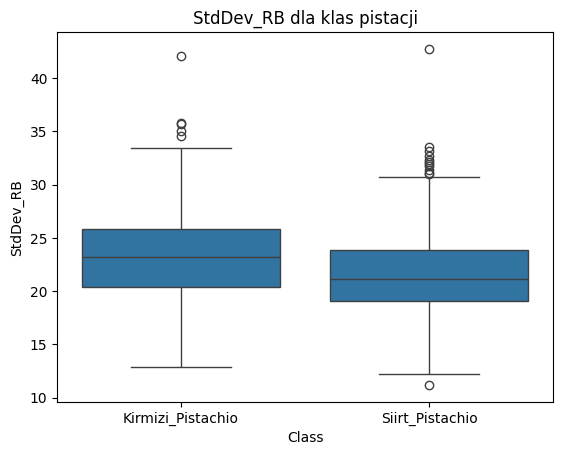

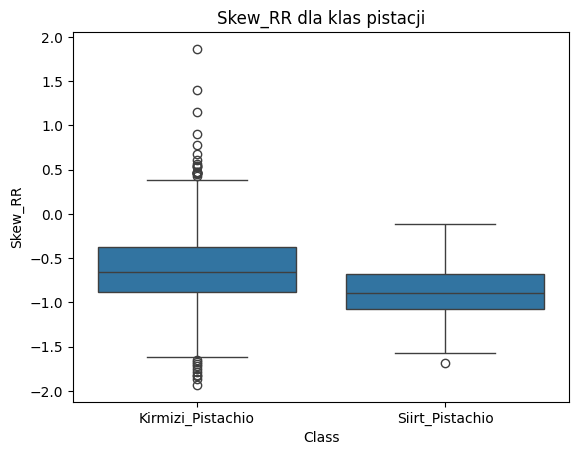

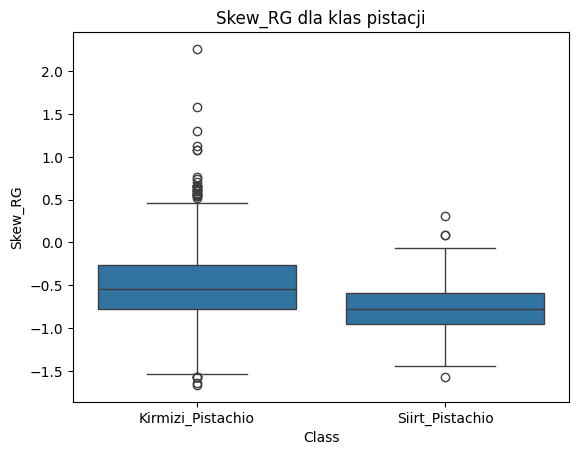

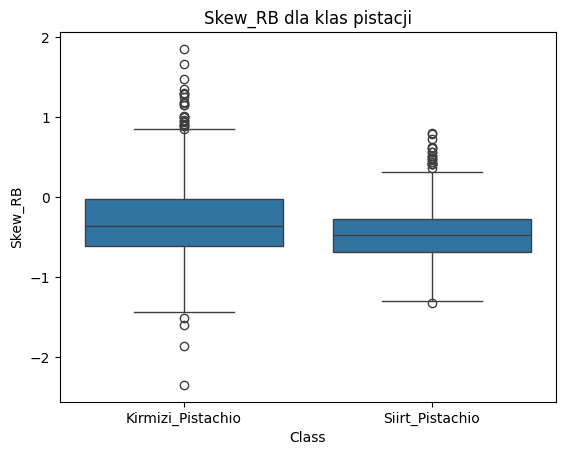

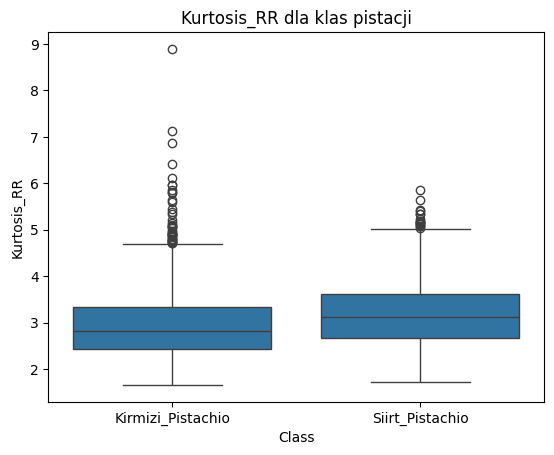

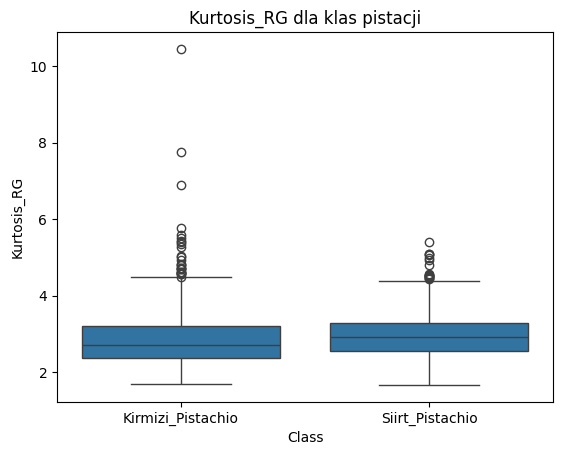

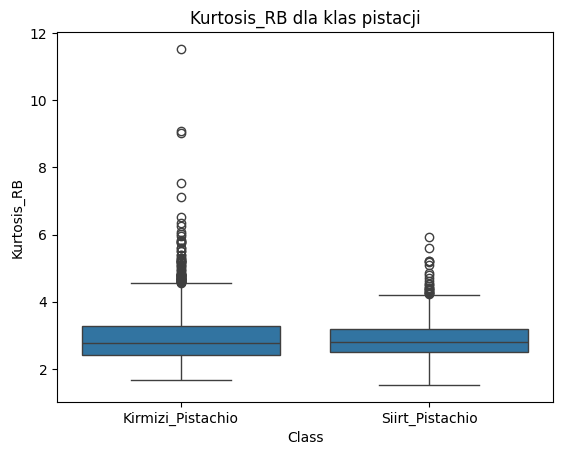

In [61]:
for col in num_cols:
    sns.boxplot(data=df, x='Class', y= df[col])
    plt.title(f"{col} dla klas pistacji")
    plt.show()
    print("\n")

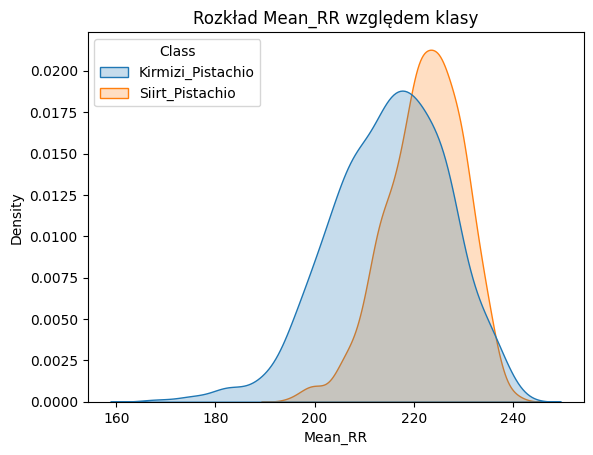

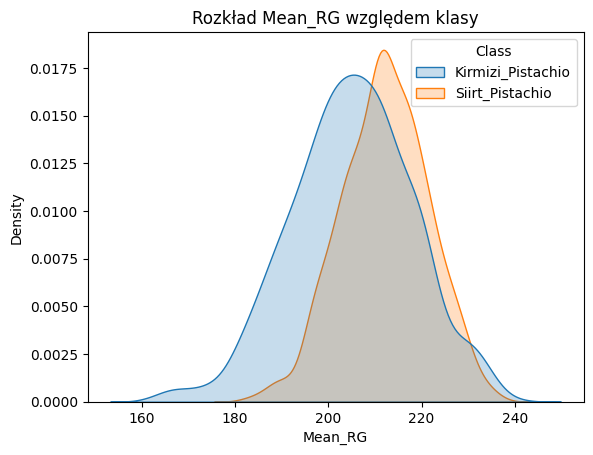

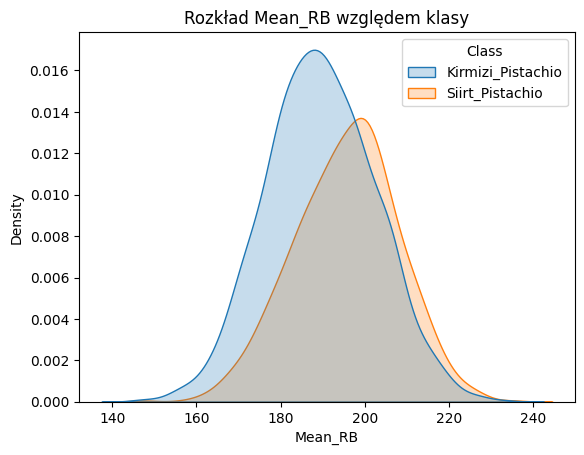

In [51]:
# natężenie kolorów
for col in ['Mean_RR', 'Mean_RG', 'Mean_RB']:
    plt.figure()
    sns.kdeplot(data=df, x=col, hue='Class', fill=True)
    plt.title(f'Rozkład {col} względem klasy')
    plt.show()

In [11]:
rgb_cols = ['Mean_RR', 'Mean_RG', 'Mean_RB']
print(df[rgb_cols].describe())

           Mean_RR      Mean_RG      Mean_RB
count  2148.000000  2148.000000  2148.000000
mean    218.067505   207.973008   191.995311
std      10.793178    12.073221    13.030505
min     167.191300   162.623000   146.787600
25%     211.608950   200.437100   182.930675
50%     219.529800   208.885000   192.036350
75%     225.941500   216.494700   201.097725
max     241.275200   240.506500   235.000700


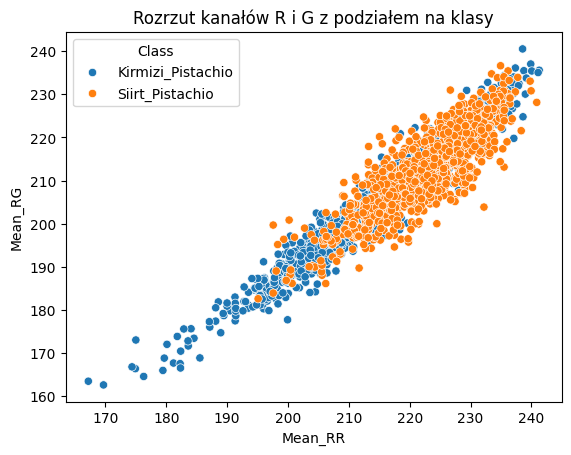

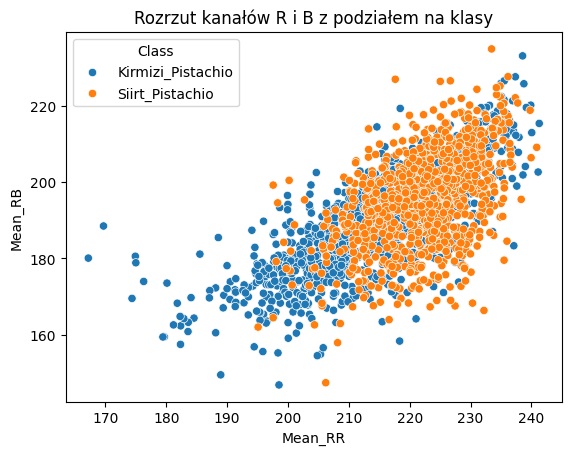

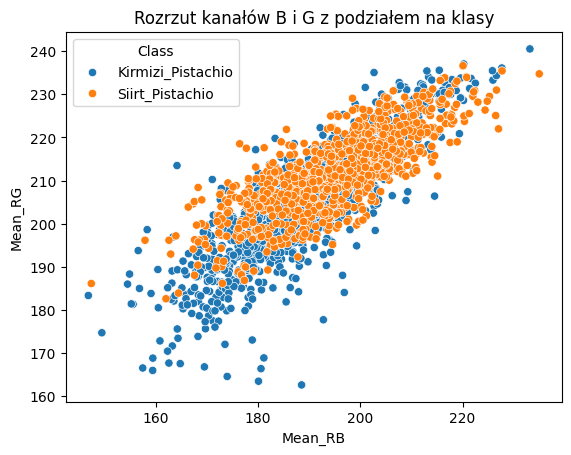

In [36]:
sns.scatterplot(x='Mean_RR', y='Mean_RG', data=df, hue='Class')
plt.title("Rozrzut kanałów R i G z podziałem na klasy")
plt.show()

sns.scatterplot(x='Mean_RR', y='Mean_RB', data=df, hue='Class')
plt.title("Rozrzut kanałów R i B z podziałem na klasy")
plt.show()

sns.scatterplot(x='Mean_RB', y='Mean_RG', data=df, hue='Class')
plt.title("Rozrzut kanałów B i G z podziałem na klasy")
plt.show()

In [34]:
df['mean_intensity'] = df[['Mean_RR', 'Mean_RG', 'Mean_RB']].mean(axis=1)
outliers = df[df['mean_intensity'] < 100] 
print(outliers[['mean_intensity', 'Class']])

Empty DataFrame
Columns: [mean_intensity, Class]
Index: []


In [44]:
#wykrywanie anomalii

from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

svm = OneClassSVM(nu=0.05, kernel="rbf", gamma='scale')
df['anomaly_svm'] = svm.fit_predict(X_scaled)

# -1 to anomalia, 1 to przypadek normalny
print(df['anomaly_svm'].value_counts())

anomaly_svm
 1    2039
-1     109
Name: count, dtype: int64


In [45]:
df_anom = df[df['anomaly_svm'] == -1]
df_norm = df[df['anomaly_svm'] == 1]

rgb_cols = ['Mean_RR', 'Mean_RG', 'Mean_RB']
print(">>> Średnie RGB - ANOMALIE:\n", df_anom[rgb_cols].describe())   #Anomalie są ciemniejsze
print(">>> Średnie RGB - NORMALNE:\n", df_norm[rgb_cols].describe())

print("\n>>> Rozkład klas w anomaliach:")         #anomalia nie oznacza błędnej etykiety, tylko nietypową obserwację niezależnie od klasy
print(df_anom['Class'].value_counts())

geom_cols = ['Eccentricity', 'Area'] + [col for col in df.columns if col.startswith('Shapefactor')]
print("\n>>> Cechy geometryczne - ANOMALIE:\n", df_anom[geom_cols].describe())
print(">>> Cechy geometryczne - NORMALNE:\n", df_norm[geom_cols].describe())     #mniejsze, mniej wydłużone i mniej zwarte

>>> Średnie RGB - ANOMALIE:
           Mean_RR     Mean_RG     Mean_RB
count  109.000000  109.000000  109.000000
mean   208.779636  198.712309  185.171227
std     17.812435   19.398656   18.035449
min    167.191300  162.623000  147.368100
25%    197.790800  183.334500  171.050100
50%    209.869400  197.860700  181.474600
75%    222.952900  215.606800  197.956500
max    241.275200  240.506500  233.176900
>>> Średnie RGB - NORMALNE:
            Mean_RR      Mean_RG      Mean_RB
count  2039.000000  2039.000000  2039.000000
mean    218.564012   208.468062   192.360110
std      10.052311    11.348343    12.610077
min     182.273500   167.559600   146.787600
25%     212.373900   201.015850   183.475950
50%     219.786800   209.116100   192.270700
75%     226.012050   216.528050   201.187150
max     241.092700   237.008400   235.000700

>>> Rozkład klas w anomaliach:
Class
Kirmizi_Pistachio    75
Siirt_Pistachio      34
Name: count, dtype: int64

>>> Cechy geometryczne - ANOMALIE:
        Ecc

In [46]:
#weryfikacja plików
folder_path = "Pistachio_Image_Dataset/Siirt_Pistachio"

errors = []

for filename in os.listdir(folder_path):
    if not filename.lower().endswith(('.jpg')):
        continue

    file_path = os.path.join(folder_path, filename)

    try:
        # Sprawdzenie czy plik istnieje i ma sensowny rozmiar
        file_size_kb = os.path.getsize(file_path) / 1024
        if file_size_kb < 5:
            errors.append((filename, "Za mały plik (<5KB)"))
            continue

        # Próba wczytania i weryfikacji obrazu
        with Image.open(file_path) as img:
            img.verify()  # szybka weryfikacja formatu


        #sprawdzenie rozmiaru
        with Image.open(file_path).convert('RGB') as img:
            if img.size[0] < 20 or img.size[1] < 20:
                errors.append((filename, "Za mały rozmiar obrazu"))
                continue

            # Sprawdzenie zawartości (czy nie jest całkowicie czarny)
            img_np = np.array(img)
            non_black_pixels = np.sum(np.any(img_np > 10, axis=2))
            if non_black_pixels < 100:
                errors.append((filename, "Obraz prawie pusty lub czarny"))

    except Exception as e:
        errors.append((filename, f"Błąd przy otwieraniu: {e}"))

print(f"\nZnaleziono {len(errors)} problematycznych obrazów na {len(os.listdir(folder_path))}:")
for fname, problem in errors:
    print(f"{fname}: {problem}")


Znaleziono 0 problematycznych obrazów na 916:


In [47]:
folder_path = "Pistachio_Image_Dataset/Kirmizi_Pistachio"
errors = []

for filename in os.listdir(folder_path):
    if not filename.lower().endswith(('.jpg')):
        continue 

    file_path = os.path.join(folder_path, filename)

    try:
        file_size_kb = os.path.getsize(file_path) / 1024
        if file_size_kb < 5:
            errors.append((filename, "Za mały plik (<5KB)"))
            continue

        with Image.open(file_path) as img:
            img.verify() 

        with Image.open(file_path).convert('RGB') as img:
            if img.size[0] < 20 or img.size[1] < 20:
                errors.append((filename, "Za mały rozmiar obrazu"))
                continue

            img_np = np.array(img)
            non_black_pixels = np.sum(np.any(img_np > 10, axis=2))
            if non_black_pixels < 100:
                errors.append((filename, "Obraz prawie pusty lub czarny"))

    except Exception as e:
        errors.append((filename, f"Błąd przy otwieraniu: {e}"))

print(f"\nZnaleziono {len(errors)} problematycznych obrazów na {len(os.listdir(folder_path))}:")
for fname, problem in errors:
    print(f"{fname}: {problem}")


Znaleziono 0 problematycznych obrazów na 1232:
